# End-to-End Loan Data Analysis in Python

**Dataset:** `loansdata.csv`  
**Target variable:** `not.fully.paid`

### Meaning of Target Variable

- `0` = Loan was fully paid
- `1` = Loan was **not** fully paid

### What this notebook covers

1. Loading the data
2. Understanding the dataset
3. Exploratory Data Analysis — EDA
4. Missing value treatment
5. Data cleaning and preprocessing
6. Data wrangling
7. Data aggregation using `groupby`
8. Data visualization
9. Correlation analysis
10. Hypothesis testing
    - Chi-Square Test
    - Independent Samples T-Test
11. Final business insights

## 1. Import Required Libraries

We first import the Python libraries needed for data analysis, visualization, and statistical testing.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

# Show charts inside the notebook
%matplotlib inline

# Improve display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Load the Dataset

Make sure `loansdata.csv` is in the same folder as this notebook.

In [2]:
loan = pd.read_csv('loansdata.csv')
loan.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.1000,11.3504,19.4800,737,5639.9583,28854,52.1000,0.0000,0.0000,0.0000,0
1,1,credit_card,0.1071,228.2200,11.0821,14.2900,707,2760.0000,33623,76.7000,0.0000,0.0000,0.0000,0
2,1,debt_consolidation,0.1357,366.8600,10.3735,11.6300,682,4710.0000,3511,25.6000,1.0000,0.0000,0.0000,0
3,1,debt_consolidation,0.1008,162.3400,11.3504,8.1000,712,2699.9583,33667,73.2000,1.0000,0.0000,0.0000,0
4,1,credit_card,0.1426,102.9200,11.2997,14.9700,667,4066.0000,4740,39.5000,0.0000,1.0000,0.0000,0


### Insight

At a first glance, we can see columns related to borrower profile, loan purpose, interest rate, credit score, and repayment status.

## 3. Basic Data Understanding

Let us check the size, columns, data types, and structure of the dataset.

In [3]:
loan.shape

(9578, 14)

The dataset has **9578 rows** and **14 columns**.

In [4]:
loan.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

In [5]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9574 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9549 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9516 non-null   float64
 10  inq.last.6mths     9549 non-null   float64
 11  delinq.2yrs        9549 non-null   float64
 12  pub.rec            9549 non-null   float64
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(9), int64(4), object(1)
memory usage: 1.0+ MB


### Explanation

`info()` helps us understand:

- Number of rows
- Number of columns
- Data types
- Missing values

### Insight

Most columns are numerical. The column `purpose` is categorical.

## 4. Statistical Summary

Now let us look at the basic statistical summary of numerical columns.

In [6]:
loan.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.0000,9578.0000,9578.0000,9574.0000,9578.0000,9578.0000,9549.0000,9578.0000,9516.0000,9549.0000,9549.0000,9549.0000,9578.0000
mean,0.8050,0.1226,319.0894,10.9319,12.6067,710.8463,4562.0261,16913.9639,46.8657,1.5716,0.1638,0.0621,0.1601
std,0.3962,0.0268,207.0713,0.6147,6.8840,37.9705,2497.9857,33756.1896,29.0186,2.1981,0.5467,0.2622,0.3667
min,0.0000,0.0600,15.6700,7.5475,0.0000,612.0000,178.9583,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1.0000,0.1039,163.7700,10.5584,7.2125,682.0000,2820.0000,3187.0000,22.7000,0.0000,0.0000,0.0000,0.0000
50%,1.0000,0.1221,268.9500,10.9280,12.6650,707.0000,4139.9583,8596.0000,46.4000,1.0000,0.0000,0.0000,0.0000
75%,1.0000,0.1407,432.7625,11.2898,17.9500,737.0000,5730.0000,18249.5000,71.0000,2.0000,0.0000,0.0000,0.0000
max,1.0000,0.2164,940.1400,14.5284,29.9600,827.0000,17639.9583,1207359.0000,119.0000,33.0000,13.0000,5.0000,1.0000


### Explanation

`describe()` gives:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

### Possible Insights

- Average interest rate can be observed from `int.rate`.
- Average credit score can be observed from `fico`.
- Variables like `revol.bal` may contain very large values, indicating possible outliers.

## 5. Check Missing Values

Missing values are common in real-world datasets. Let us check them.

In [7]:
missing_values = loan.isnull().sum().sort_values(ascending=False)
missing_values

revol.util           62
days.with.cr.line    29
inq.last.6mths       29
delinq.2yrs          29
pub.rec              29
log.annual.inc        4
dti                   0
installment           0
int.rate              0
purpose               0
credit.policy         0
fico                  0
revol.bal             0
not.fully.paid        0
dtype: int64

In [8]:
missing_percentage = (loan.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage

revol.util          0.6473
days.with.cr.line   0.3028
inq.last.6mths      0.3028
delinq.2yrs         0.3028
pub.rec             0.3028
log.annual.inc      0.0418
dti                 0.0000
installment         0.0000
int.rate            0.0000
purpose             0.0000
credit.policy       0.0000
fico                0.0000
revol.bal           0.0000
not.fully.paid      0.0000
dtype: float64

### Insight

Some variables contain missing values, such as:

- `revol.util`
- `days.with.cr.line`
- `inq.last.6mths`
- `delinq.2yrs`
- `pub.rec`
- `log.annual.inc`

The percentage of missing values is small, so simple imputation is acceptable for beginner-level analysis.

## 6. Missing Value Imputation

For this beginner-friendly analysis, we will use:

- Median imputation for numerical columns
- Mode imputation for categorical columns

Median is safer than mean when the data has outliers.

In [10]:
# Separate numerical and categorical columns
num_cols = loan.select_dtypes(include=np.number).columns
cat_cols = loan.select_dtypes(include='object').columns

# Fill missing numerical values with median
for col in num_cols:
    loan[col] = loan[col].fillna(loan[col].median())

# Fill missing categorical values with mode
for col in cat_cols:
    loan[col] = loan[col].fillna(loan[col].mode()[0])

# Verify missing values again
loan.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

All columns should now show `0` missing values.

## 7. Duplicate Check

Duplicates can distort analysis. Let us check if duplicate rows are present.

In [11]:
loan.duplicated().sum()

np.int64(0)

### Explanation

If the output is `0`, there are no duplicate rows.

If duplicates are present, you can remove them using:

```python
loan = loan.drop_duplicates()
```

## 8. Target Variable Analysis

The target variable is `not.fully.paid`.

Let us check how many borrowers fully paid and how many did not.

In [12]:
loan['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

In [13]:
loan['not.fully.paid'].value_counts(normalize=True) * 100

not.fully.paid
0   83.9946
1   16.0054
Name: proportion, dtype: float64

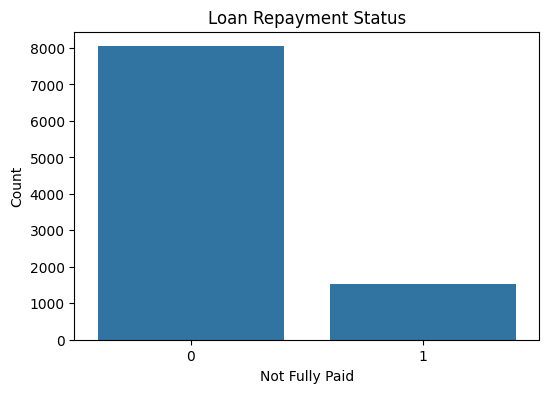

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='not.fully.paid', data=loan)
plt.title('Loan Repayment Status')
plt.xlabel('Not Fully Paid')
plt.ylabel('Count')
plt.show()

### Insight

The number of fully paid loans is much higher than not fully paid loans.

This means the dataset is **imbalanced**. In classification problems, imbalance is important because a model may become biased toward the majority class.

## 9. EDA: Loan Purpose Distribution

Let us analyze why people are taking loans.

In [15]:
loan['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

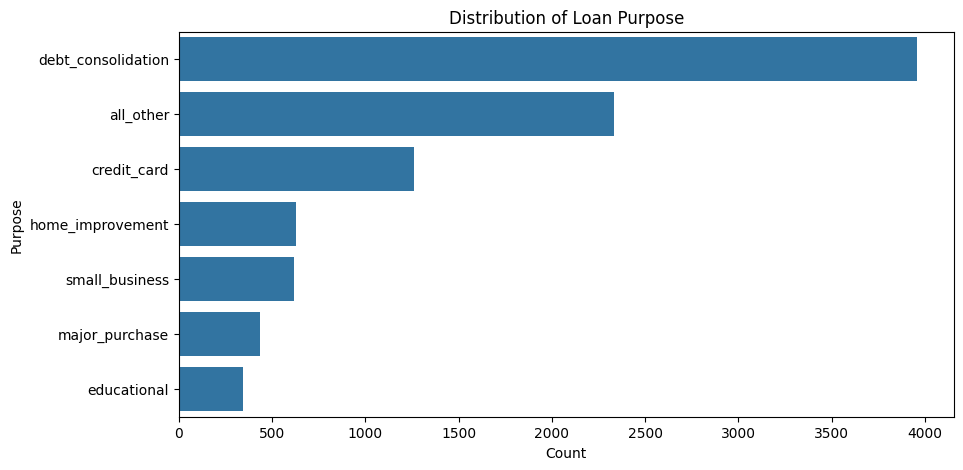

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y='purpose', data=loan, order=loan['purpose'].value_counts().index)
plt.title('Distribution of Loan Purpose')
plt.xlabel('Count')
plt.ylabel('Purpose')
plt.show()

### Insight

Common loan purposes are usually debt consolidation, credit card, and other personal purposes.

This is useful because borrower behavior may differ by loan purpose.

## 10. EDA: Numerical Variable Distributions

Let us visualize important numerical variables.

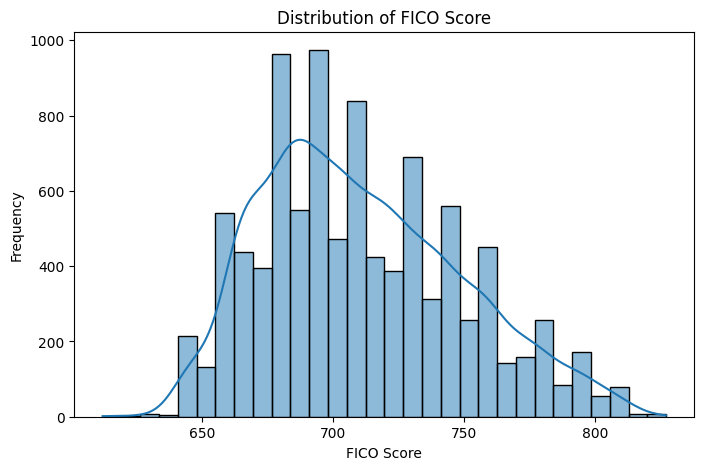

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(loan['fico'], bins=30, kde=True)
plt.title('Distribution of FICO Score')
plt.xlabel('FICO Score')
plt.ylabel('Frequency')
plt.show()

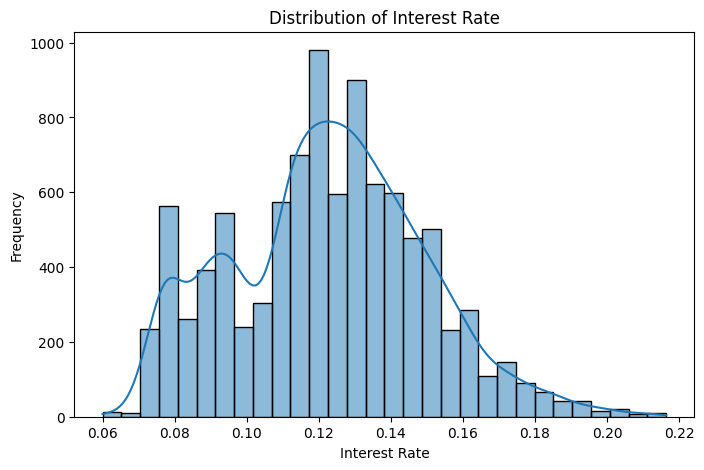

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(loan['int.rate'], bins=30, kde=True)
plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.show()

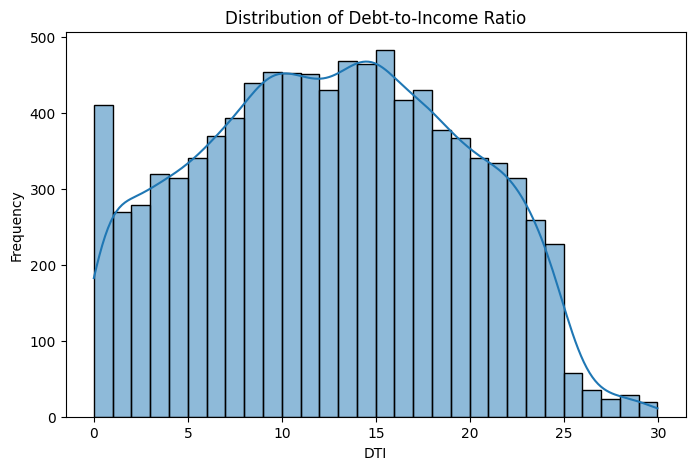

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(loan['dti'], bins=30, kde=True)
plt.title('Distribution of Debt-to-Income Ratio')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

### Insights

- FICO score gives an idea of borrower creditworthiness.
- Interest rate may be higher for risky borrowers.
- DTI shows how much debt a borrower has compared to income.

## 11. Compare Variables with Target

Now we compare important numerical variables against `not.fully.paid`.

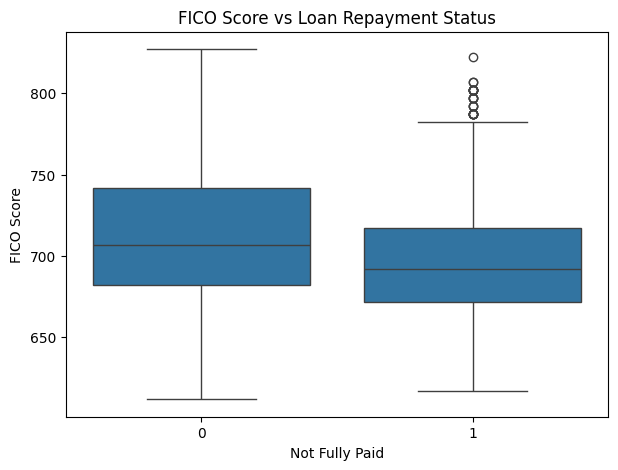

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='not.fully.paid', y='fico', data=loan)
plt.title('FICO Score vs Loan Repayment Status')
plt.xlabel('Not Fully Paid')
plt.ylabel('FICO Score')
plt.show()

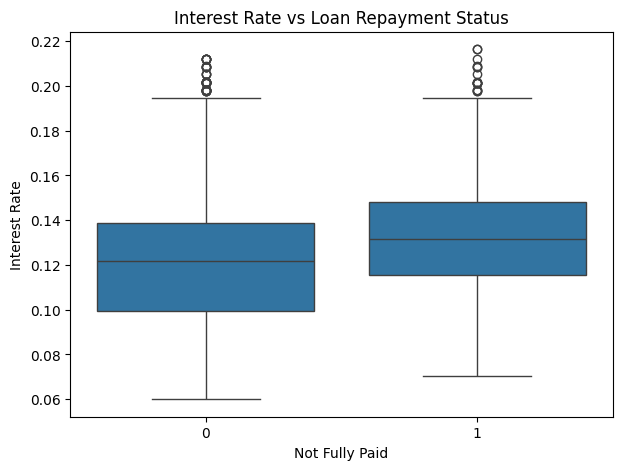

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='not.fully.paid', y='int.rate', data=loan)
plt.title('Interest Rate vs Loan Repayment Status')
plt.xlabel('Not Fully Paid')
plt.ylabel('Interest Rate')
plt.show()

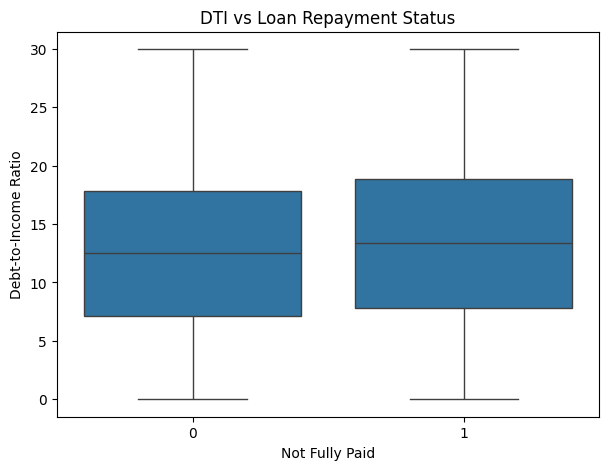

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x='not.fully.paid', y='dti', data=loan)
plt.title('DTI vs Loan Repayment Status')
plt.xlabel('Not Fully Paid')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

### Expected Insights

- Borrowers who do not fully pay loans may have lower FICO scores.
- Borrowers who do not fully pay loans may have higher interest rates.
- DTI may also be higher for riskier borrowers.

# 12. Data Wrangling and Feature Engineering

Data wrangling means transforming raw data into more useful forms.

We will create some simple new variables.

In [23]:
# Create interest rate category
loan['interest_category'] = pd.cut(
    loan['int.rate'],
    bins=[0, 0.10, 0.15, 0.30],
    labels=['Low', 'Medium', 'High']
)

# Create FICO category
loan['fico_category'] = pd.cut(
    loan['fico'],
    bins=[600, 660, 720, 850],
    labels=['Low FICO', 'Medium FICO', 'High FICO']
)

# Create DTI category
loan['dti_category'] = pd.cut(
    loan['dti'],
    bins=[0, 10, 20, 40],
    labels=['Low DTI', 'Medium DTI', 'High DTI']
)

loan[['int.rate', 'interest_category', 'fico', 'fico_category', 'dti', 'dti_category']].head()

,int.rate,interest_category,fico,fico_category,dti,dti_category
0,0.1189,Medium,737,High FICO,19.4800,Medium DTI
1,0.1071,Medium,707,Medium FICO,14.2900,Medium DTI
2,0.1357,Medium,682,Medium FICO,11.6300,Medium DTI
3,0.1008,Medium,712,Medium FICO,8.1000,Low DTI
4,0.1426,Medium,667,Medium FICO,14.9700,Medium DTI


### Explanation

We converted continuous numerical variables into categories:

- Interest rate → Low, Medium, High
- FICO → Low, Medium, High
- DTI → Low, Medium, High

This makes analysis easier for beginners and business users.

# 13. Data Aggregation Using `groupby`

`groupby` is used to summarize data by categories.

For example:

```python
loan.groupby('purpose')['not.fully.paid'].mean()
```

This means:

> For each loan purpose, calculate the average value of `not.fully.paid`.

Since `not.fully.paid` is 0 or 1, the mean becomes the default rate.

## 13.1 Average Default Rate by Loan Purpose

In [24]:
default_by_purpose = loan.groupby('purpose')['not.fully.paid'].mean().sort_values(ascending=False)
default_by_purpose

purpose
small_business       0.2779
educational          0.2012
home_improvement     0.1701
all_other            0.1660
debt_consolidation   0.1524
credit_card          0.1157
major_purchase       0.1121
Name: not.fully.paid, dtype: float64

### Insight

This shows which loan purposes have higher default risk.

A value of `0.20` means around 20% of loans in that category were not fully paid.

## 13.2 Count of Loans by Purpose

In [25]:
loan_count_by_purpose = loan.groupby('purpose')['not.fully.paid'].count().sort_values(ascending=False)
loan_count_by_purpose

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: not.fully.paid, dtype: int64

### Explanation

This tells us how many loans are present for each purpose.

## 13.3 Average FICO Score by Loan Status

In [26]:
loan.groupby('not.fully.paid')['fico'].mean()

not.fully.paid
0   713.3269
1   697.8284
Name: fico, dtype: float64

### Insight

If the average FICO score is lower for `not.fully.paid = 1`, it means credit score is an important risk indicator.

## 13.4 Average Interest Rate by Loan Status

In [27]:
loan.groupby('not.fully.paid')['int.rate'].mean()

not.fully.paid
0   0.1208
1   0.1325
Name: int.rate, dtype: float64

### Insight

If interest rate is higher for `not.fully.paid = 1`, it suggests higher-risk borrowers are charged higher interest rates.

## 13.5 Multiple Aggregations by Loan Status

We can calculate multiple summaries together.

In [28]:
loan.groupby('not.fully.paid').agg({
    'fico': ['mean', 'median', 'min', 'max'],
    'int.rate': ['mean', 'median'],
    'installment': ['mean', 'median'],
    'dti': ['mean', 'median']
})

fico                    int.rate        installment  \
                   mean   median  min  max     mean median        mean   
not.fully.paid                                                           
0              713.3269 707.0000  612  827   0.1208 0.1218    314.5741   
1              697.8284 692.0000  617  822   0.1325 0.1316    342.7851   

                            dti          
                 median    mean  median  
not.fully.paid                           
0              266.5200 12.4944 12.5300  
1              287.3100 13.1958 13.3400

### Explanation

This gives several statistics for each repayment status group.

### Insight

This table helps compare borrower profiles between fully paid and not fully paid groups.

## 13.6 Aggregation by Purpose with Multiple Metrics

In [29]:
purpose_summary = loan.groupby('purpose').agg(
    total_loans=('not.fully.paid', 'count'),
    default_rate=('not.fully.paid', 'mean'),
    avg_fico=('fico', 'mean'),
    avg_interest_rate=('int.rate', 'mean'),
    avg_installment=('installment', 'mean'),
    avg_dti=('dti', 'mean')
).sort_values(by='default_rate', ascending=False)

purpose_summary

,total_loans,default_rate,avg_fico,avg_interest_rate,avg_installment,avg_dti
purpose,,,,,,
small_business,619,0.2779,719.9887,0.1381,433.8266,10.7933
educational,343,0.2012,708.2828,0.1199,217.5472,11.3449
home_improvement,629,0.1701,724.8060,0.1175,337.0716,10.1975
all_other,2331,0.1660,715.3441,0.1168,244.9375,11.0795
debt_consolidation,3957,0.1524,703.8714,0.1266,358.9844,14.0765
credit_card,1262,0.1157,709.6268,0.1197,319.5007,14.0994
major_purchase,437,0.1121,722.5034,0.1142,243.4839,10.1599


This is a clean business summary table.

For every loan purpose, we calculate:
- Total loans
- Default rate
- Average FICO
- Average interest rate
- Average installment
- Average DTI

### Insight
This table helps identify high-risk loan purposes.

## 13.7 Default Rate by Interest Category

In [30]:
loan.groupby('interest_category')['not.fully.paid'].mean().sort_values(ascending=False)

C:\Users\Vikash.Singh\AppData\Local\Temp\ipykernel_26308\103960422.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan.groupby('interest_category')['not.fully.paid'].mean().sort_values(ascending=False)


interest_category
High     0.2475
Medium   0.1708
Low      0.0741
Name: not.fully.paid, dtype: float64

### Insight

High interest loan categories may show a higher default rate.

## 13.8 Default Rate by FICO Category

In [31]:
loan.groupby('fico_category')['not.fully.paid'].mean().sort_values(ascending=False)

C:\Users\Vikash.Singh\AppData\Local\Temp\ipykernel_26308\376244681.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan.groupby('fico_category')['not.fully.paid'].mean().sort_values(ascending=False)


fico_category
Low FICO      0.3088
Medium FICO   0.1844
High FICO     0.1033
Name: not.fully.paid, dtype: float64

### Insight

Low FICO customers are expected to have a higher default rate.

## 13.9 Two-Level Grouping: Purpose and Loan Status

In [32]:
loan.groupby(['purpose', 'not.fully.paid'])['fico'].mean()

purpose             not.fully.paid
all_other           0                718.6049
                    1                698.9638
credit_card         0                711.5654
                    1                694.8082
debt_consolidation  0                705.9475
                    1                692.3234
educational         0                711.3431
                    1                696.1304
home_improvement    0                728.0920
                    1                708.7757
major_purchase      0                724.7191
                    1                704.9592
small_business      0                724.2260
                    1                708.9767
Name: fico, dtype: float64

### Explanation

This gives average FICO score for each combination of:

- Loan purpose
- Repayment status

This is useful when we want deeper segmented analysis.

## 13.10 Two-Level Grouping with Multiple Metrics

In [33]:
loan.groupby(['purpose', 'not.fully.paid']).agg(
    avg_fico=('fico', 'mean'),
    avg_interest_rate=('int.rate', 'mean'),
    avg_dti=('dti', 'mean'),
    avg_installment=('installment', 'mean'),
    loan_count=('not.fully.paid', 'count')
)

avg_fico  avg_interest_rate  avg_dti  \
purpose            not.fully.paid                                         
all_other          0               718.6049             0.1147  10.9162   
                   1               698.9638             0.1273  11.8999   
credit_card        0               711.5654             0.1182  14.0363   
                   1               694.8082             0.1313  14.5818   
debt_consolidation 0               705.9475             0.1254  13.9566   
                   1               692.3234             0.1333  14.7433   
educational        0               711.3431             0.1176  11.1379   
                   1               696.1304             0.1291  12.1671   
home_improvement   0               728.0920             0.1150  10.0157   
                   1               708.7757             0.1295  11.0843   
major_purchase     0               724.7191             0.1125  10.1325   
                   1               704.9592             0.1275  10.3769   
small_business     0               724.2260             0.1348  10.3139   
                   1               708.9767             0.1466  12.0392   

                                   avg_installment  loan_count  
purpose            not.fully.paid                               
all_other          0                      242.7896        1944  
                   1                      255.7274         387  
credit_card        0                      314.1711        1116  
                   1                      360.2393         146  
debt_consolidation 0                      359.3921        3354  
                   1                      356.7165         603  
educational        0                      210.5929         274  
                   1                      245.1629          69  
home_improvement   0                      327.7546         522  
                   1                      382.5247         107  
major_purchase     0                      229.8493         388  
                   1                      351.4476          49  
small_business     0                      413.3734         447  
                   1                      486.9813         172

### Insight

This gives a detailed comparison across purpose and repayment status.

It is useful for risk teams that want to understand which borrower segments are risky.

## 13.11 Pivot Table Example

Pivot tables are another simple way to summarize data.

In [34]:
pd.pivot_table(
    loan,
    values='not.fully.paid',
    index='purpose',
    columns='interest_category',
    aggfunc='mean'
)

C:\Users\Vikash.Singh\AppData\Local\Temp\ipykernel_26308\4191170083.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


interest_category,Low,Medium,High
purpose,,,
all_other,0.0886,0.1863,0.2789
credit_card,0.0355,0.1341,0.1894
debt_consolidation,0.0794,0.1557,0.2103
educational,0.0778,0.2286,0.3256
home_improvement,0.0667,0.1972,0.3108
major_purchase,0.0397,0.1545,0.1250
small_business,0.1264,0.2767,0.3362


### Explanation

This table shows default rate by:

- Loan purpose
- Interest category

### Insight

This helps identify combinations such as high-interest small-business loans or high-interest debt-consolidation loans that may have higher default rates.

## 13.12 Aggregation with Custom Risk Flag

Let us create a simple risk flag and summarize it.

In [35]:
loan['high_risk_flag'] = np.where(
    (loan['fico'] < 670) & (loan['int.rate'] > 0.15),
    'High Risk',
    'Normal Risk'
)

loan.groupby('high_risk_flag').agg(
    total_loans=('not.fully.paid', 'count'),
    default_rate=('not.fully.paid', 'mean'),
    avg_fico=('fico', 'mean'),
    avg_interest_rate=('int.rate', 'mean')
)

,total_loans,default_rate,avg_fico,avg_interest_rate
high_risk_flag,,,,
High Risk,677,0.2688,659.2304,0.1662
Normal Risk,8901,0.1518,714.7722,0.1193


### Explanation

We created a simple business rule:

A borrower is marked as **High Risk** if:

- FICO score is below 670
- Interest rate is above 15%

### Insight

This is not a machine learning model, but it is a simple business-rule-based risk segmentation.

# 14. Visualization of Aggregated Data

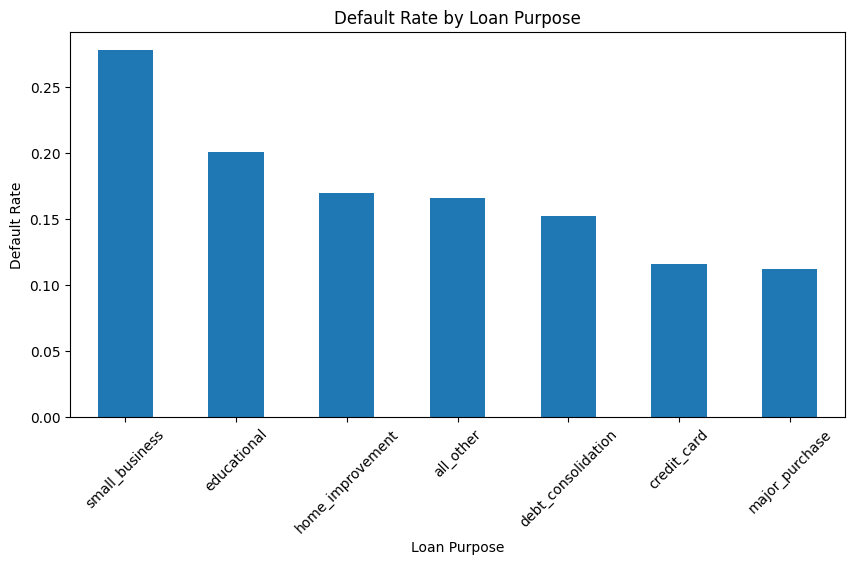

In [36]:
plt.figure(figsize=(10,5))
default_by_purpose.plot(kind='bar')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

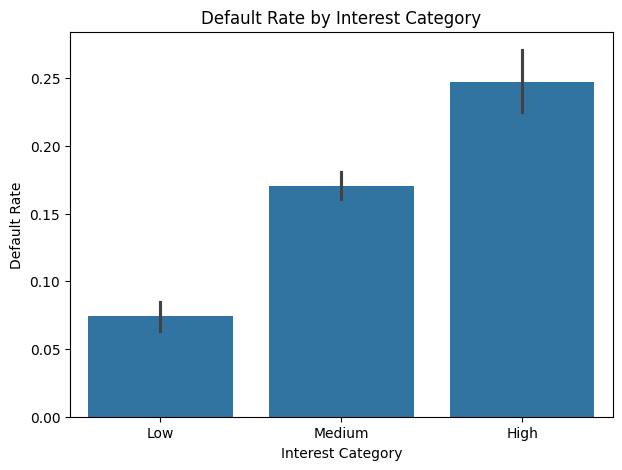

In [37]:
plt.figure(figsize=(7,5))
sns.barplot(x='interest_category', y='not.fully.paid', data=loan)
plt.title('Default Rate by Interest Category')
plt.xlabel('Interest Category')
plt.ylabel('Default Rate')
plt.show()

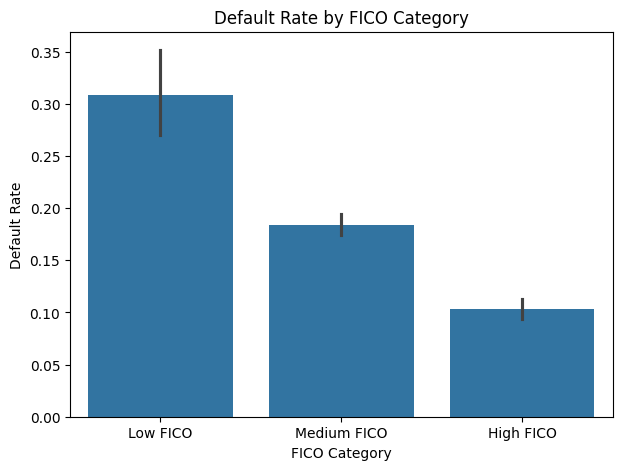

In [38]:
plt.figure(figsize=(7,5))
sns.barplot(x='fico_category', y='not.fully.paid', data=loan)
plt.title('Default Rate by FICO Category')
plt.xlabel('FICO Category')
plt.ylabel('Default Rate')
plt.show()

### Insight

These charts help communicate results clearly to non-technical audiences.

# 15. Correlation Analysis

Correlation helps us understand relationships between numerical variables.

In [39]:
corr = loan.corr(numeric_only=True)
corr

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
credit.policy,1.0000,-0.2941,0.0588,0.0357,-0.0909,0.3483,0.0991,-0.1875,-0.1088,-0.5297,-0.0748,-0.0527,-0.1581
int.rate,-0.2941,1.0000,0.2761,0.0571,0.2200,-0.7148,-0.1237,0.0925,0.4617,0.2070,0.1567,0.0989,0.1596
installment,0.0588,0.2761,1.0000,0.4485,0.0502,0.0860,0.1835,0.2336,0.0794,-0.0073,-0.0038,-0.0319,0.0500
log.annual.inc,0.0357,0.0571,0.4485,1.0000,-0.0534,0.1136,0.3351,0.3725,0.0556,0.0285,0.0295,0.0165,-0.0333
dti,-0.0909,0.2200,0.0502,-0.0534,1.0000,-0.2412,0.0605,0.1887,0.3357,0.0316,-0.0214,0.0066,0.0374
fico,0.3483,-0.7148,0.0860,0.1136,-0.2412,1.0000,0.2629,-0.0156,-0.5392,-0.1876,-0.2163,-0.1473,-0.1497
days.with.cr.line,0.0991,-0.1237,0.1835,0.3351,0.0605,0.2629,1.0000,0.2296,-0.0239,-0.0419,0.0818,0.0714,-0.0288
revol.bal,-0.1875,0.0925,0.2336,0.3725,0.1887,-0.0156,0.2296,1.0000,0.2022,0.0242,-0.0329,-0.0307,0.0537
revol.util,-0.1088,0.4617,0.0794,0.0556,0.3357,-0.5392,-0.0239,0.2022,1.0000,-0.0113,-0.0427,0.0673,0.0817
inq.last.6mths,-0.5297,0.2070,-0.0073,0.0285,0.0316,-0.1876,-0.0419,0.0242,-0.0113,1.0000,0.0214,0.0742,0.1499


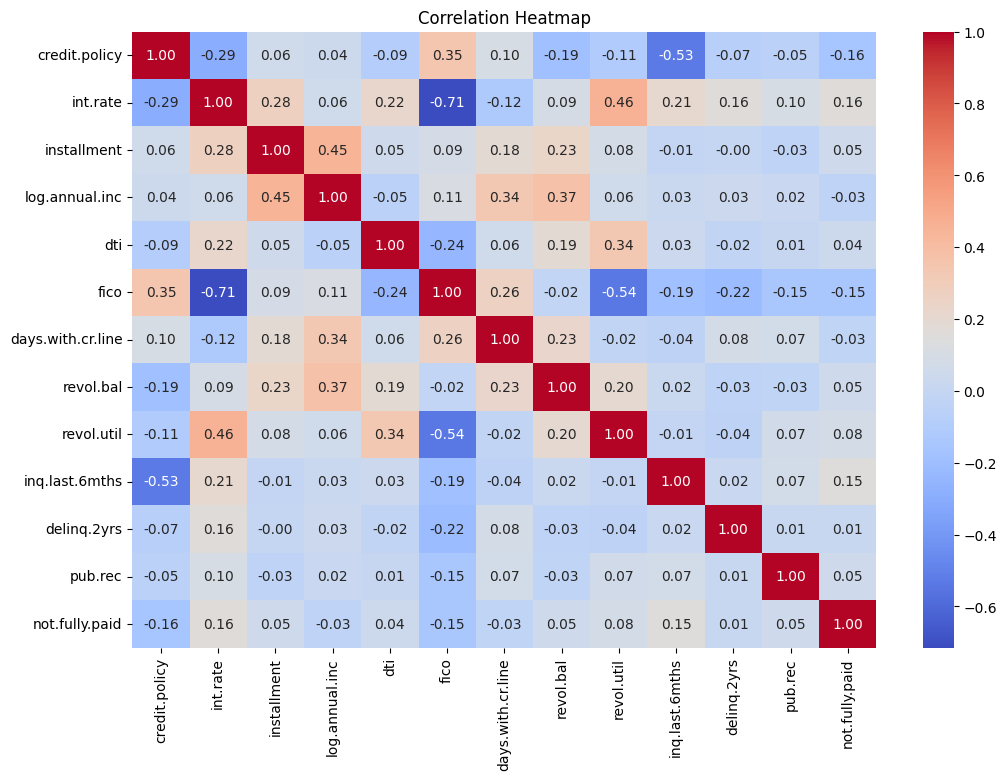

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Explanation

Correlation values range from:

- `+1`: Strong positive relationship
- `-1`: Strong negative relationship
- `0`: No linear relationship

### Expected Insights

- `fico` may have a negative relationship with `not.fully.paid`.
- `int.rate` may have a positive relationship with `not.fully.paid`.
- `fico` and `int.rate` may be negatively related because lower FICO borrowers may receive higher rates.

# 16. Hypothesis Testing

Hypothesis testing helps us check whether observed differences are statistically meaningful.

We will perform:

1. Independent Samples T-Test
2. Chi-Square Test

## 16.1 T-Test: Is FICO Score Different for Paid and Not Fully Paid Loans?

### Business Question

Do borrowers who fully paid loans and borrowers who did not fully pay loans have significantly different FICO scores?

### Hypotheses

- **H0:** Average FICO score is the same for both groups.
- **H1:** Average FICO score is different for both groups.

In [41]:
fully_paid_fico = loan[loan['not.fully.paid'] == 0]['fico']
not_fully_paid_fico = loan[loan['not.fully.paid'] == 1]['fico']

t_stat, p_value = ttest_ind(fully_paid_fico, not_fully_paid_fico, equal_var=False)

print('T-Statistic:', t_stat)
print('P-Value:', p_value)

if p_value < 0.05:
    print('Conclusion: Reject H0. FICO scores are significantly different between the two groups.')
else:
    print('Conclusion: Fail to reject H0. No significant difference found.')

T-Statistic: 16.115079788003577
P-Value: 1.709081294104472e-55
Conclusion: Reject H0. FICO scores are significantly different between the two groups.


### Insight

If the p-value is less than 0.05, we conclude that FICO score differs significantly between fully paid and not fully paid borrowers.

## 16.2 T-Test: Is Interest Rate Different for Paid and Not Fully Paid Loans?

### Business Question

Do borrowers who do not fully pay loans have significantly different interest rates?

### Hypotheses

- **H0:** Average interest rate is the same for both groups.
- **H1:** Average interest rate is different for both groups.

In [42]:
fully_paid_rate = loan[loan['not.fully.paid'] == 0]['int.rate']
not_fully_paid_rate = loan[loan['not.fully.paid'] == 1]['int.rate']

t_stat, p_value = ttest_ind(fully_paid_rate, not_fully_paid_rate, equal_var=False)

print('T-Statistic:', t_stat)
print('P-Value:', p_value)

if p_value < 0.05:
    print('Conclusion: Reject H0. Interest rates are significantly different between the two groups.')
else:
    print('Conclusion: Fail to reject H0. No significant difference found.')

T-Statistic: -16.31683268925947
P-Value: 1.2911259817723516e-56
Conclusion: Reject H0. Interest rates are significantly different between the two groups.


### Insight

If the p-value is less than 0.05, interest rate is statistically associated with repayment behavior.

## 16.3 Chi-Square Test: Is Loan Purpose Associated with Default?

### Business Question

Is loan purpose related to whether a borrower fully pays the loan or not?

### Hypotheses

- **H0:** Loan purpose and repayment status are independent.
- **H1:** Loan purpose and repayment status are associated.

In [43]:
contingency_table = pd.crosstab(loan['purpose'], loan['not.fully.paid'])
contingency_table

not.fully.paid,0,1
purpose,,
all_other,1944,387
credit_card,1116,146
debt_consolidation,3354,603
educational,274,69
home_improvement,522,107
major_purchase,388,49
small_business,447,172


In [44]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print('Chi-Square Statistic:', chi2)
print('P-Value:', p)
print('Degrees of Freedom:', dof)

if p < 0.05:
    print('Conclusion: Reject H0. Loan purpose is associated with repayment status.')
else:
    print('Conclusion: Fail to reject H0. No significant association found.')

Chi-Square Statistic: 96.98469589063261
P-Value: 1.0672453117980422e-18
Degrees of Freedom: 6
Conclusion: Reject H0. Loan purpose is associated with repayment status.


### Insight

If the p-value is less than 0.05, loan purpose and repayment status are statistically associated.

## 16.4 Chi-Square Test: Is Interest Category Associated with Default?

In [45]:
contingency_table_interest = pd.crosstab(loan['interest_category'], loan['not.fully.paid'])
contingency_table_interest

not.fully.paid,0,1
interest_category,,
Low,2023,162
Medium,4958,1021
High,1064,350


In [46]:
chi2, p, dof, expected = chi2_contingency(contingency_table_interest)

print('Chi-Square Statistic:', chi2)
print('P-Value:', p)
print('Degrees of Freedom:', dof)

if p < 0.05:
    print('Conclusion: Reject H0. Interest category is associated with repayment status.')
else:
    print('Conclusion: Fail to reject H0. No significant association found.')

Chi-Square Statistic: 205.53738652182267
P-Value: 2.3341222813612595e-45
Degrees of Freedom: 2
Conclusion: Reject H0. Interest category is associated with repayment status.


### Insight

This test checks whether low, medium, and high interest categories have different default behavior.

# 17. Outlier Detection

Outliers are extreme values. They can affect averages and models.

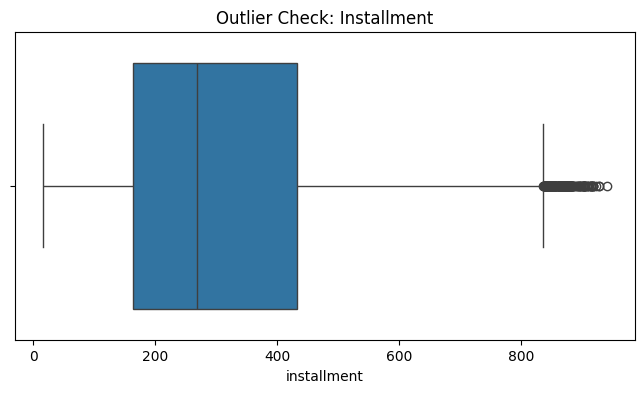

In [47]:
plt.figure(figsize=(8,4))
sns.boxplot(x=loan['installment'])
plt.title('Outlier Check: Installment')
plt.show()

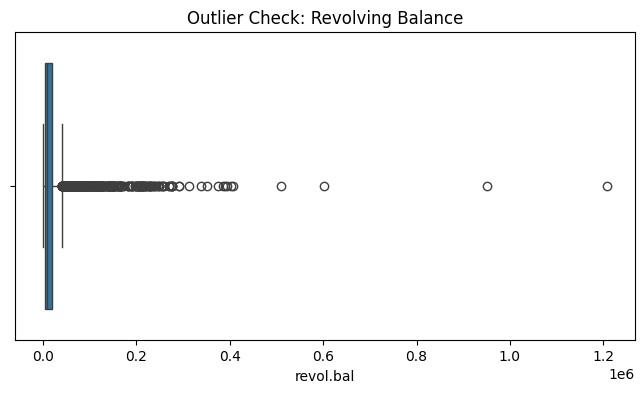

In [48]:
plt.figure(figsize=(8,4))
sns.boxplot(x=loan['revol.bal'])
plt.title('Outlier Check: Revolving Balance')
plt.show()

### Insight

`revol.bal` may show large outliers because some borrowers may have very high revolving balances.

For beginner-level EDA, we only observe outliers. In advanced modeling, we may treat them using capping or transformation.

# 18. Final Insights

Based on this analysis, we coe up with these insights:

## 1. The dataset is imbalanced

Most borrowers fully paid their loans. Fewer borrowers did not fully pay.

## 2. FICO score is important

Borrowers with lower FICO scores tend to have higher default risk.

## 3. Interest rate is important

Borrowers with higher interest rates tend to show higher default risk.

## 4. Loan purpose matters

Some loan purposes may have higher default rates than others.

## 5. Groupby analysis is very powerful

Using `groupby`, we can quickly summarize:

- Default rate by purpose
- Average FICO by repayment status
- Average interest rate by loan status
- Risk by interest category
- Risk by FICO category

## 6. Hypothesis testing supports EDA

Statistical tests help confirm whether differences seen in charts are meaningful.

# 19. Optional Next Step: Machine Learning

After this EDA, you all should try to build a simple classification model.

link: https://medium.com/@vikashsinghy2k/credit-risk-modelling-in-python-c1a374866a73

Possible models:

- Logistic Regression
- Decision Tree
- Random Forest

Possible evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because the dataset is imbalanced, accuracy alone may not be enough.